# Day 5: Matplotlib — Data Visualization

## Learning Objectives

By the end of this notebook, I will be able to:

- Understand why data visualization is important.
- Create different types of plots using Matplotlib.
- Create labeled line, scatter, bar, and histogram plots.
- Use subplots to compare multiple visualizations.
- Combine NumPy, Pandas, and Matplotlib in a complete data analysis workflow.

# Why Visualization Matters

Data is often stored as tables containing many numbers, but it can be difficult to discover patterns by only looking at raw data.

Data visualization transforms numbers into visual representations that make it easier to identify:

- Trends and changes over time.
- Relationships between variables.
- Patterns in data.
- Outliers and unusual values.

Visualization is used in two main ways:

1. **Exploration:**  
   Helping data analysts understand the dataset and discover hidden patterns.

2. **Communication:**  
   Presenting results clearly to others.

Visualization is an essential part of Exploratory Data Analysis (EDA), where we explore and understand data before building machine learning models.

# Matplotlib Basics

Matplotlib is a Python library used to create data visualizations.

The standard workflow for creating a plot is:

1. Import the pyplot module.
2. Prepare the data.
3. Choose the suitable plot type.
4. Add labels and a title.
5. Display the visualization.

Every visualization should include clear labels because an unlabeled chart is difficult to understand.

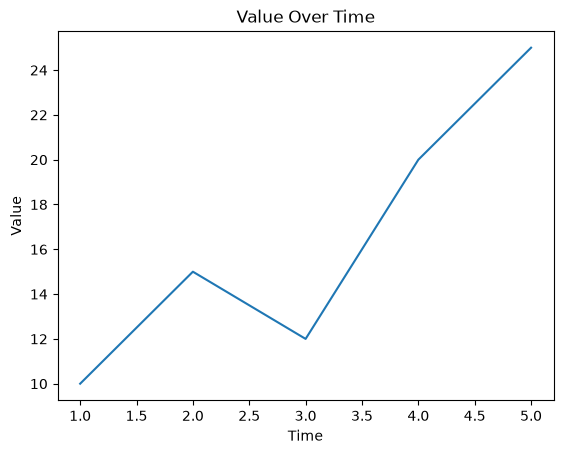

In [1]:
import matplotlib.pyplot as plt

x = [1, 2, 3, 4, 5]
y = [10, 15, 12, 20, 25]

plt.plot(x, y)

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Value Over Time")

plt.show()

# The Four Core Plot Types

Matplotlib provides different plot types depending on the purpose of visualization.

The four main types are:

1. Line Plot
2. Scatter Plot
3. Bar Chart
4. Histogram

## 1. Line Plot

A line plot is used to show trends or changes over a continuous axis, usually time.

Examples:

- Temperature changes during days.
- Company growth over months.
- Stock prices over time.

Function used:

`plt.plot()`

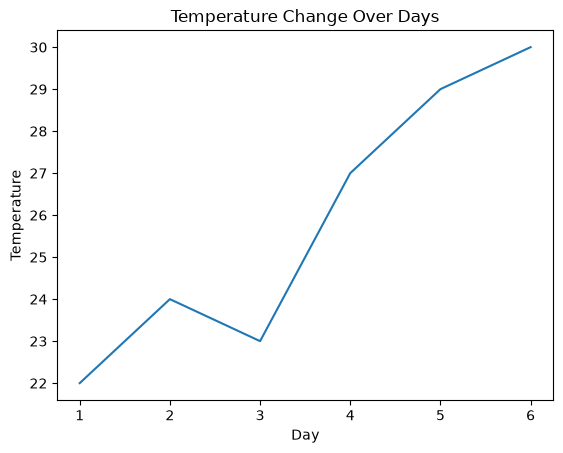

In [2]:
days = [1, 2, 3, 4, 5, 6]

temperature = [22, 24, 23, 27, 29, 30]

plt.plot(days, temperature)

plt.xlabel("Day")
plt.ylabel("Temperature")
plt.title("Temperature Change Over Days")

plt.show()

## 2. Scatter Plot

Scatter plots show the relationship between two numerical variables.

They help us understand:

- Whether variables are related.
- The strength of relationships.
- Possible clusters or unusual values.

Function used:

`plt.scatter()`

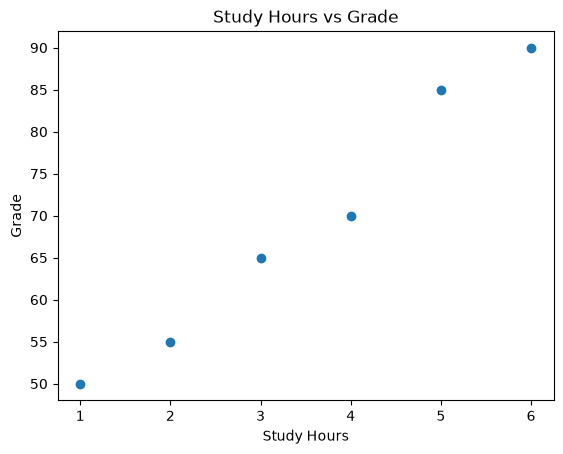

In [3]:
hours = [1, 2, 3, 4, 5, 6]

grades = [50, 55, 65, 70, 85, 90]

plt.scatter(hours, grades)

plt.xlabel("Study Hours")
plt.ylabel("Grade")
plt.title("Study Hours vs Grade")

plt.show()

## 3. Bar Chart

A bar chart is used to compare values between different categories.

Examples:

- Number of students in each department.
- Sales of different products.
- Comparing performance between groups.

Function used:

`plt.bar()`

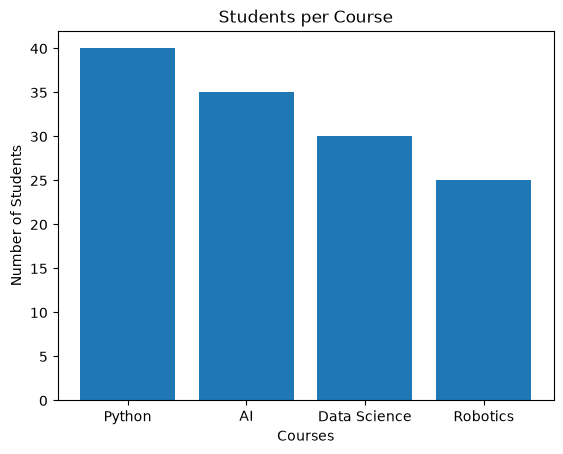

In [4]:
courses = ["Python", "AI", "Data Science", "Robotics"]

students = [40, 35, 30, 25]

plt.bar(courses, students)

plt.xlabel("Courses")
plt.ylabel("Number of Students")
plt.title("Students per Course")

plt.show()

## 4. Histogram

A histogram is used to understand the distribution of a single numerical variable.

It helps us identify:

- The most common values.
- The spread of data.
- The shape of the distribution.

Function used:

`plt.hist()`

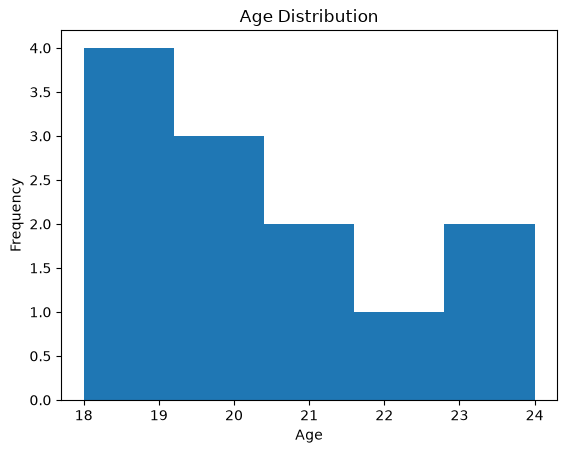

In [6]:
ages = [18,19,20,21,22,20,19,18,23,24,21,20]

plt.hist(ages, bins=5)

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")

plt.show()

# Subplots

Sometimes we need to compare multiple visualizations together.

Subplots allow us to place multiple plots inside one figure.

This is useful in Exploratory Data Analysis (EDA) because we can compare different aspects of the dataset at the same time.

The main function is:

`plt.subplots()`

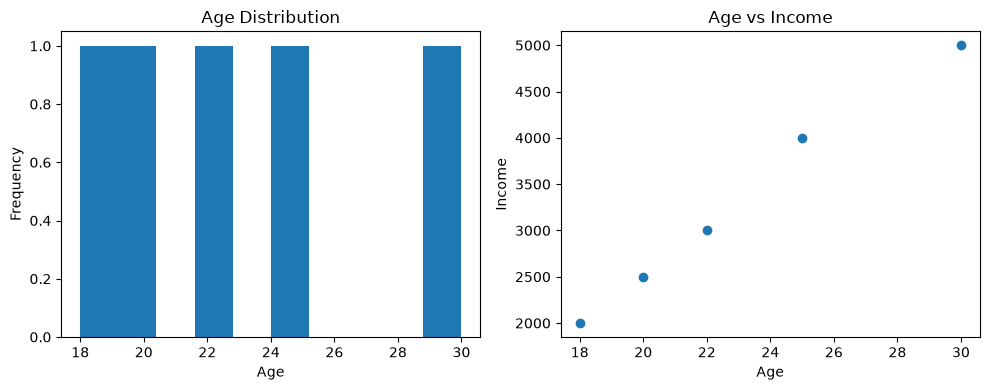

In [7]:
import pandas as pd

data = {
    "age": [18,20,22,25,30],
    "income": [2000,2500,3000,4000,5000]
}

df = pd.DataFrame(data)


fig, axes = plt.subplots(1, 2, figsize=(10,4))


axes[0].hist(df["age"])

axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")


axes[1].scatter(df["age"], df["income"])

axes[1].set_title("Age vs Income")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Income")


plt.tight_layout()

plt.show()

# Hands-On Lab: Student Data Analysis

In this project, we will:

1. Load and clean a dataset using Pandas.
2. Use NumPy to create a calculated feature.
3. Create different visualizations.
4. Explain what each visualization shows.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

## Step 1: Load Dataset

We start by loading the dataset using Pandas.

In [17]:
df = pd.read_csv("students_Courses.csv")

df.head()

,StudentID,Name,StudyTime,Score,Level,Completed,City
0,801,Ali,2.0,70.0,Beginner,Yes,Nablus
1,802,Sara,5.0,85.0,beginner,Yes,Ramallah
2,803,Omar,NaN,60.0,Intermediate,No,nablus
3,804,Lina,10.0,150.0,Advanced,Yes,Jenin
4,805,Noor,-3.0,40.0,Intermediate,No,Jenin


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   StudentID  12 non-null     int64  
 1   Name       12 non-null     str    
 2   StudyTime  11 non-null     float64
 3   Score      11 non-null     float64
 4   Level      12 non-null     str    
 5   Completed  12 non-null     str    
 6   City       12 non-null     str    
dtypes: float64(2), int64(1), str(4)
memory usage: 804.0 bytes


## Step 1 (continued): Cleaning the Data

Before analyzing anything, I need to check for missing values, invalid values, and inconsistent text formatting.

In [12]:
df.isnull().sum()

StudentID    0
Name         0
StudyTime    1
Score        1
Level        0
Completed    0
City         0
dtype: int64

### Observation

`StudyTime` is missing for one student, and `Score` is missing for another. Since the dataset is small (only 12 rows), dropping these rows would lose valuable data. I filled each missing value with the column's mean instead, to keep the dataset size while still using a statistically reasonable estimate.

In [18]:
df["StudyTime"] = df["StudyTime"].fillna(df["StudyTime"].mean())
df["Score"] = df["Score"].fillna(df["Score"].mean())

df.isnull().sum()

StudentID    0
Name         0
StudyTime    0
Score        0
Level        0
Completed    0
City         0
dtype: int64

### Standardizing Text Values

The `Level` and `City` columns have inconsistent capitalization (e.g. `Beginner`, `beginner`, `ADVANCED` are all the same category). I standardized them using `.str.title()` so they are treated as one consistent value instead of several different ones.

In [19]:
print("Before:", df["Level"].unique())

df["Level"] = df["Level"].str.title()
df["City"] = df["City"].str.title()
df["Completed"] = df["Completed"].str.title()

print("After:", df["Level"].unique())

Before: <StringArray>
['Beginner', 'beginner', 'Intermediate', 'Advanced', 'advanced', 'ADVANCED']
Length: 6, dtype: str
After: <StringArray>
['Beginner', 'Intermediate', 'Advanced']
Length: 3, dtype: str


### Removing Invalid Values

Looking at the data, two values don't make sense: a negative `StudyTime` (-3 hours) and a `Score` of 150 (scores should be between 0 and 100). These are almost certainly data-entry errors, so I removed those rows rather than keep clearly impossible values that would distort the analysis.

In [20]:
df = df[(df["Score"] >= 0) & (df["Score"] <= 100)]
df = df[df["StudyTime"] >= 0]
df = df.reset_index(drop=True)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   StudentID  10 non-null     int64  
 1   Name       10 non-null     str    
 2   StudyTime  10 non-null     float64
 3   Score      10 non-null     float64
 4   Level      10 non-null     str    
 5   Completed  10 non-null     str    
 6   City       10 non-null     str    
dtypes: float64(2), int64(1), str(4)
memory usage: 692.0 bytes


### Final Cleaning Summary

After cleaning, the dataset has no missing values, consistent category names, and no out-of-range values. It's now ready for analysis.

## Step 2: Numerical Analysis with NumPy

I'll compute a few summary statistics, and then a **derived feature**: `Score_per_Hour`, which shows how much score a student earns per hour of study — a simple measure of study efficiency, not just raw score.

In [21]:
average_score = np.mean(df["Score"])
average_time = np.mean(df["StudyTime"])
score_std = np.std(df["Score"])
median_score = np.median(df["Score"])

print(f"Average Score: {average_score:.2f}")
print(f"Average Study Time: {average_time:.2f} hours")
print(f"Score Standard Deviation: {score_std:.2f}")
print(f"Median Score: {median_score:.2f}")

Average Score: 74.60
Average Study Time: 4.32 hours
Score Standard Deviation: 13.33
Median Score: 74.00


### Observation

The mean and median scores are close to each other, which suggests the scores are fairly evenly spread rather than skewed by one extreme value.

In [22]:
# Derived feature: how much score a student earns per hour of studying
# (np.where avoids a division-by-zero error for the student with 0 study hours)
df["Score_per_Hour"] = np.where(df["StudyTime"] > 0, df["Score"] / df["StudyTime"], np.nan)

df[["Name", "StudyTime", "Score", "Score_per_Hour"]]

,Name,StudyTime,Score,Score_per_Hour
0,Ali,2.000000,70.0,35.000000
1,Sara,5.000000,85.0,17.000000
2,Omar,4.181818,60.0,14.347826
3,Ali,2.000000,70.0,35.000000
4,Ahmad,6.000000,78.0,13.000000
5,Huda,4.000000,88.0,22.000000
6,Rana,0.000000,50.0,NaN
7,Yousef,12.000000,95.0,7.916667
8,Mona,3.000000,65.0,21.666667
9,Kareem,5.000000,85.0,17.000000


### Observation

`Score_per_Hour` reveals something the raw score alone doesn't: a student with a lower score but very little study time can actually be more *efficient* than a student with a higher score who studied much longer. This is a good example of how a derived feature can surface a pattern hidden in the raw columns.

## Step 3: Data Visualization with Matplotlib

### 3.1 Histogram — Score Distribution

A histogram shows how the scores are spread across different ranges.

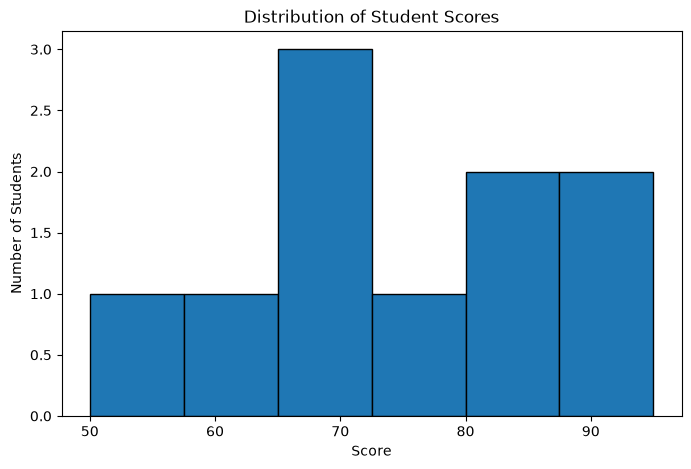

In [23]:
plt.figure(figsize=(8, 5))
plt.hist(df["Score"], bins=6, edgecolor="black")
plt.xlabel("Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Student Scores")
plt.show()

**What this reveals:** most students score between 65 and 90, with no extreme outliers left after cleaning — the invalid 150 score removed earlier would have distorted this chart.

### 3.2 Scatter Plot — Study Time vs. Score

A scatter plot shows the relationship between two numeric variables — here, whether studying more hours relates to a higher score.

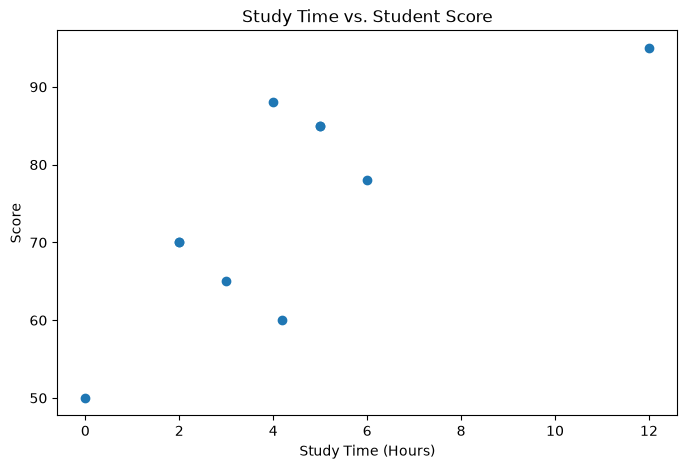

In [24]:
plt.figure(figsize=(8, 5))
plt.scatter(df["StudyTime"], df["Score"])
plt.xlabel("Study Time (Hours)")
plt.ylabel("Score")
plt.title("Study Time vs. Student Score")
plt.show()

**What this reveals:** there's a general upward trend — students who studied more hours tend to score higher — but it isn't a perfectly straight line, meaning study time alone doesn't fully determine the score.

### 3.3 Bar Chart — Average Score by Course Level

A bar chart compares a value across categories — here, the average score for each course level.

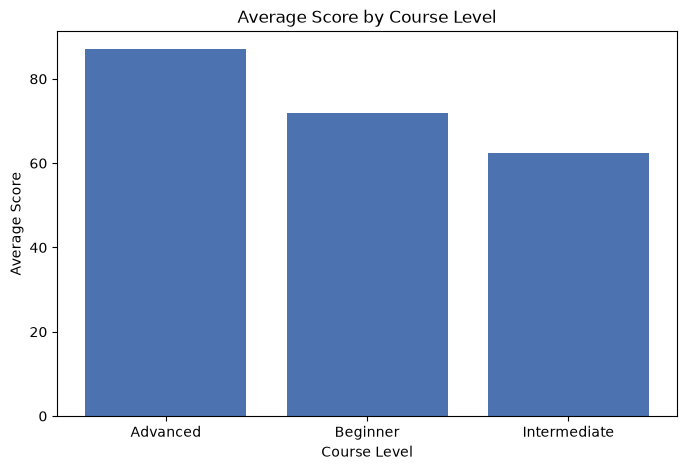

In [26]:
average_by_level = df.groupby("Level")["Score"].mean()

plt.figure(figsize=(8, 5))
plt.bar(average_by_level.index, average_by_level.values, color="#4C72B0")
plt.xlabel("Course Level")
plt.ylabel("Average Score")
plt.title("Average Score by Course Level")
plt.show()

**What this reveals:** average scores increase from Beginner to Advanced, which makes sense — students further along in the course track tend to perform better.

### 3.4 Line Plot — Sorted Scores

This dataset has no time dimension, so a line plot doesn't show a trend over time. Instead, I sorted the scores to show the overall shape of the distribution as a line, which highlights how gradually (or sharply) scores increase from lowest to highest.

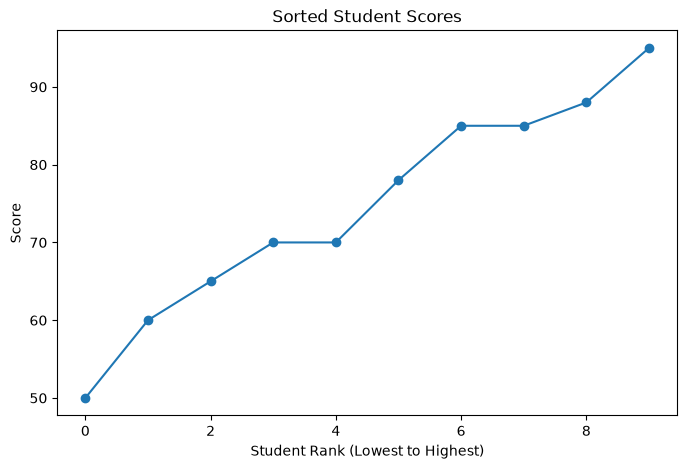

In [27]:
sorted_scores = np.sort(df["Score"])

plt.figure(figsize=(8, 5))
plt.plot(sorted_scores, marker="o")
plt.xlabel("Student Rank (Lowest to Highest)")
plt.ylabel("Score")
plt.title("Sorted Student Scores")
plt.show()

**What this reveals:** the line rises fairly steadily with no big jumps, which supports the earlier finding (mean ≈ median) that scores are evenly spread rather than clustered with a few extreme outliers.

## Step 3 (continued): Subplots — Side-by-Side Comparison

Combining the histogram and the scatter plot in one figure makes it easy to compare the overall score distribution against the study-time relationship at a glance.

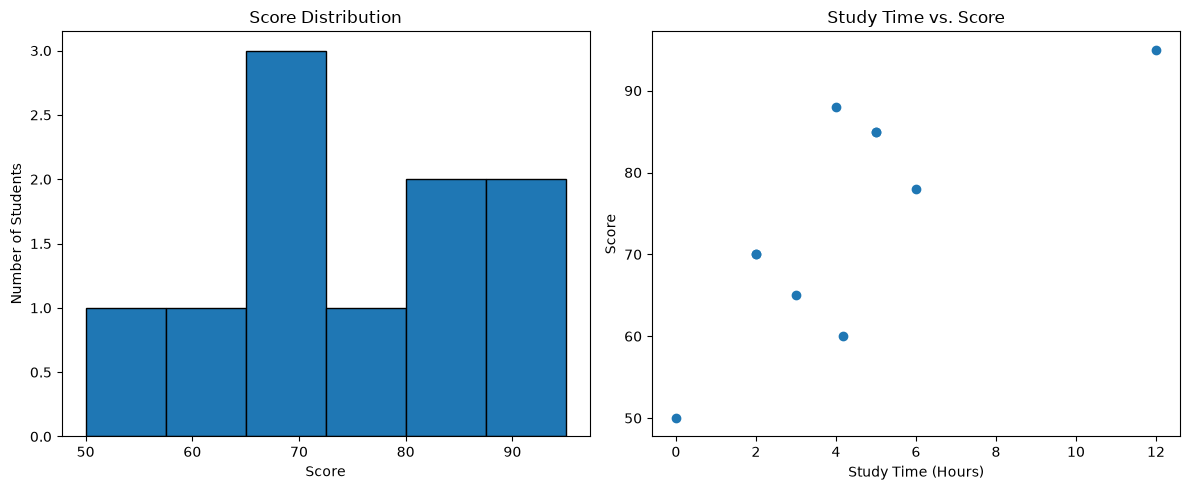

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["Score"], bins=6, edgecolor="black")
axes[0].set_title("Score Distribution")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Number of Students")

axes[1].scatter(df["StudyTime"], df["Score"])
axes[1].set_title("Study Time vs. Score")
axes[1].set_xlabel("Study Time (Hours)")
axes[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

# Conclusion

In this notebook, I learned how to visualize data using Matplotlib.

I learned when to use different visualization types:

- Line Plot → Showing trends over time.
- Scatter Plot → Exploring relationships between variables.
- Bar Chart → Comparing categories.
- Histogram → Understanding data distribution.

I also learned how to combine NumPy, Pandas, and Matplotlib together in a complete data analysis workflow.

These skills are important for Exploratory Data Analysis (EDA) and future machine learning projects.